In [14]:
import pandas as pd
import seaborn as sns

In [15]:
df = pd.read_csv('../Data/Raw/Sample - Superstore.csv', encoding='latin1')

In [16]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].head(20)

,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164
5,48.8600,7,0.00,14.1694
6,7.2800,4,0.00,1.9656
7,907.1520,6,0.20,90.7152
8,18.5040,3,0.20,5.7825
9,114.9000,5,0.00,34.4700


In [17]:
df['Unit Price'] = df['Sales'] / df['Quantity']

In [18]:
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Unit Price']].head(20)

,Sales,Quantity,Discount,Profit,Unit Price
0,261.9600,2,0.00,41.9136,130.9800
1,731.9400,3,0.00,219.5820,243.9800
2,14.6200,2,0.00,6.8714,7.3100
3,957.5775,5,0.45,-383.0310,191.5155
4,22.3680,2,0.20,2.5164,11.1840
5,48.8600,7,0.00,14.1694,6.9800
6,7.2800,4,0.00,1.9656,1.8200
7,907.1520,6,0.20,90.7152,151.1920
8,18.5040,3,0.20,5.7825,6.1680
9,114.9000,5,0.00,34.4700,22.9800


In [19]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Unit Price
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,60.919569
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,142.927440
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.336000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,5.470000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,16.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,63.940000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,3773.080000


In [20]:
df['Discount'].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [21]:
df['Sales'].corr(df['Profit'])

np.float64(0.4790643497377062)

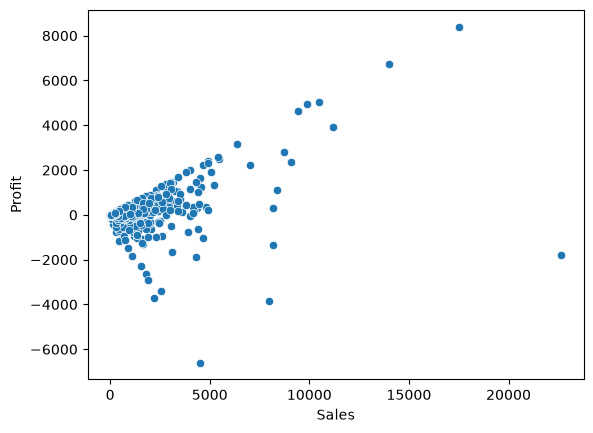

In [22]:
sns.scatterplot(data = df,
                x = 'Sales',
                y = 'Profit');

In [23]:
df.groupby('Discount')[['Sales', 'Profit']].mean()

,Sales,Profit
Discount,,
0.00,226.742074,66.900292
0.10,578.397351,96.055074
0.15,529.971567,27.288298
0.20,209.076940,24.702572
0.30,454.742974,-45.679636
0.32,536.794770,-88.560656
0.40,565.134874,-111.927429
0.45,498.634000,-226.646464
0.50,892.705152,-310.703456


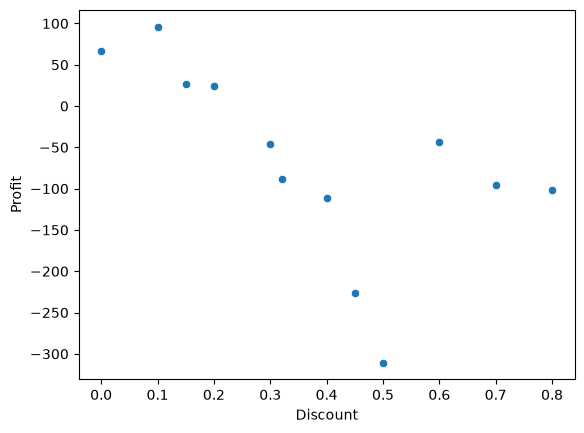

In [24]:
sns.scatterplot(data = df.groupby('Discount')[['Sales', 'Profit']].mean(),
                x = 'Discount',
                y = 'Profit');

In [25]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,130.9800
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,243.9800
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.3100
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,191.5155
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.1840


In [29]:
# 1.1 Total Revenue
print('Total Revenue = $' + str(round(df['Sales'].sum(), 2)))

# 1.2 Total Profit
print('Total Profit = $' + str(round(df['Profit'].sum(), 2)))

# 1.3 Number of Orders
#df.groupby('Order ID').size().describe()
print('Number of Orders = ' + str(df['Order ID'].nunique()))

# 1.4 Number of Unique Clients
print('Number of Unique Clients = ' + str(df['Customer ID'].nunique()))

# 1.5 Average Profit per transaction
print('Average Profit per transaction = $' + str(round(df['Profit'].mean(), 2)))

Total Revenue = $2297200.86
Total Profit = $286397.02
Number of Orders = 5009
Number of Unique Clients = 793
Average Profit per transaction = $28.66
